# Assignment 2 — Generate cashflows from bond_convention

Supply a complete `bond_convention` dictionary, construct `BondCalculator`, and call `schedule_dataframe()` to obtain cashflows.

The dictionary contains both **bond terms** (dates, coupon, face and redemption) and **market conventions** (frequency, day count, settlement and payment rules). 

Implement six methods in `analytics/bond_calculator.py`: `yield_to_price`, `_generate_bond_schedule`, `_first_period_accrual`, `_last_period_accrual`, `_regular_period_accrual`, and `_accrued_interest`. Each has a concise instruction. Complete the six #TODO methods before running the calculator examples. Other methods are provided.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
from IPython.display import display

cwd = Path.cwd().resolve()
repo_root = next((p for p in [cwd, *cwd.parents]
                  if (p / "fixedincomelib" / "analytics" / "bond_calculator.py").is_file()), None)
if repo_root is None:
    raise RuntimeError("Run from the repository or its fixedincomelib directory")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
from fixedincomelib import BondCalculator, qfCreateSchedule


## 1. Enter any supported bond's terms

This is a new illustrative bond: quarterly coupons, face 1,000, and 102% redemption. Replace these values to generate another schedule.`first accrual date` is the interest start date, which may differ from the issue date.

For irregular final periods, supply `last regular coupon date` to anchor the grid before maturity. For irregular first periods, supply the actual `first coupon date`. `schedule rule` can be `FORWARD` or `BACKWARD`. Payment-date rolling is separate from unadjusted accrual dates.

### Which convention does each calculation use?

**Day-count basis** measures interest; **Street yield** discounts the resulting cashflows. `schedule rule` determines date-generation direction, and payment conventions roll payment dates. These are separate choices.

| Accrual basis | Year fraction for an irregular coupon | Example |
|---|---|---|
| `ACT/ACT (ICMA)` | Sum `(1/f) × overlap days / reference-period days` | HMLGLO first coupon: `4 × (58/181 + 1) = 5.281768` per 100 |
| `30/360 (BOND BASIS)` | Convention-specific 30/360 day count divided by 360 | META first coupon: `100 × 0.0525 × 191/360 = 2.785417` |
| `ISMA-30/360` | Same BondBasis mapping in this library | KSA final coupon: `100 × 0.0375 × 168/360 = 1.75` |
| `ACT/360` | Actual calendar days divided by 360 | A 45-day stub at 6% on face 100 pays `100 × 0.06 × 45/360 = 0.75` |
| `ACT/365 FIXED` | Actual calendar days divided by 365 | The same stub pays `100 × 0.06 × 45/365 = 0.739726` |

Read `first period accrual basis` for the first coupon, `last period accrual basis` for the last, and `accrual basis` for interior periods. These fields can differ. The introductory quarterly example uses **ACT/ACT (ICMA) + Street discounting**.

Try to find that `AccrualBasis in market/basics.py ` is where the rules truly diverge.

### Example: schedule direction and payment-date adjustment

A bond starts accruing on **January 15, 2026**, matures on
**November 15, 2026**, and pays coupons every **6 months**.
Assume no first or last regular coupon dates are explicitly specified.

| Schedule rule | Accrual dates, in chronological order | Irregular period |
|---|---|---|
| `FORWARD` | January 15 → July 15 → November 15 | Short final period: 4 months |
| `BACKWARD` | January 15 → May 15 → November 15 | Short first period: 4 months |

`FORWARD` builds the schedule from the accrual start; `BACKWARD` builds it
from maturity. Choose the direction that matches the contractual schedule.

In **both cases**, maturity falls on **Sunday, November 15, 2026**.
With the `Following` payment convention, assuming Monday is a business day,
the final payment moves to **Monday, November 16**.

The final accrual period still ends on **November 15**.
Only the payment date moves; the extra day does not increase coupon accrual.

In [2]:
bond_convention = {'issue date': '2031-01-15',
 'first accrual date': '2031-01-15',
 'first coupon date': '2031-04-15',
 'maturity date': '2033-01-15',
 'coupon rate': 0.06,
 'face value': 1000.0,
 'redemption': 1.02,
 'coupon accrual period': '3M',
 'accrual basis': 'ACT/ACT (ICMA)',
 'first period accrual basis': 'ACT/ACT (ICMA)',
 'last period accrual basis': 'ACT/ACT (ICMA)',
 'schedule rule': 'FORWARD',
 'last regular coupon date': None,
 'end of month': False,
 'settlement business day convention': 'F',
 'settlement holiday convention': 'USGS',
 'settlement offset': '1D',
 'payment business day convention': 'F',
 'payment holiday convention': 'USGS',
 'payment offset': '0D'}


## See the underlying qfCreateSchedule call

Use API to present information you want. Drive qfCreateSchedule and see what happened behind it.
Both this cell and `_generate_bond_schedule` call the public `qfCreateSchedule` directly. The API returns dates and year fractions, but no `IsRegular` flag. The calculator reads regular/stub flags from the matching QuantLib schedule, then calculates coupons in the assignment methods.


In [3]:
# Direct API example for this regular ICMA schedule. Stub coupons are handled by BondCalculator.
periods = qfCreateSchedule(
    start_date=bond_convention["first accrual date"],
    end_date=bond_convention["maturity date"],
    accrual_period=bond_convention["coupon accrual period"],
    holiday_convention="NONE", business_day_convention="NONE",
    accrual_basis=bond_convention["accrual basis"],
    rule=bond_convention["schedule rule"],
    first_regular_date=bond_convention["first coupon date"],
    next_to_last_date=bond_convention["last regular coupon date"],
    end_of_month=bond_convention["end of month"],
    payment_offset=bond_convention["payment offset"],
    payment_offset_business_day_convention=bond_convention["payment business day convention"],
    payment_offset_holiday_convention=bond_convention["payment holiday convention"],
)
periods["Coupon"] = bond_convention["face value"] * bond_convention["coupon rate"] * periods["Accrued"]
periods["Principal"] = 0.0
periods.loc[periods.index[-1], "Principal"] = bond_convention["face value"] * bond_convention["redemption"]
periods["Total"] = periods["Coupon"] + periods["Principal"]
display(periods)


,StartDate,EndDate,StartFixingDate,EndFixingDate,PaymentDate,Accrued,Coupon,Principal,Total
0,"January 15th, 2031","April 15th, 2031","January 15th, 2031",None,"April 15th, 2031",0.25,15.0,0.0,15.0
1,"April 15th, 2031","July 15th, 2031","April 15th, 2031",None,"July 15th, 2031",0.25,15.0,0.0,15.0
2,"July 15th, 2031","October 15th, 2031","July 15th, 2031",None,"October 15th, 2031",0.25,15.0,0.0,15.0
3,"October 15th, 2031","January 15th, 2032","October 15th, 2031",None,"January 15th, 2032",0.25,15.0,0.0,15.0
4,"January 15th, 2032","April 15th, 2032","January 15th, 2032",None,"April 15th, 2032",0.25,15.0,0.0,15.0
5,"April 15th, 2032","July 15th, 2032","April 15th, 2032",None,"July 15th, 2032",0.25,15.0,0.0,15.0
6,"July 15th, 2032","October 15th, 2032","July 15th, 2032",None,"October 15th, 2032",0.25,15.0,0.0,15.0
7,"October 15th, 2032","January 15th, 2033","October 15th, 2032",None,"January 18th, 2033",0.25,15.0,1020.0,1035.0


## 2. Price the same bond

Follow the same array-based steps as the lecture example:
1. Collect the remaining coupon amounts. Express each remaining interval in coupon-period units, then use np.cumsum to obtain cumulative times from settlement.
2. Compute Street discount factors: `(1 + y/f)**(-n)`, or `1/(1 + y*n/f)` for one remaining payment in this model.
3. Compute `coupon_pv = np.dot(coupon_amounts, discount)` and add the discounted redemption.
4. Subtract accrued interest to obtain clean price.

The supplied Bloomberg yields require the Street factors above. Accrued interest is `coupon_amount * elapsed_accrual / full_period_accrual`.

The six implementation tasks have these responsibilities:
- `_generate_bond_schedule`: generate accrual/payment dates; label first, regular and last periods, and assign each period's accrual basis and regular/stub flag.
- `_first_period_accrual`: use the regular method for a normal first period; otherwise build reference periods backward and calculate the first coupon using its accrual basis. Split ICMA stubs where needed; save reference dates and the full-period year fraction.
- `_last_period_accrual`: use the regular method for a normal final period; otherwise build reference periods forward and calculate the final coupon using its accrual basis. Split ICMA stubs where needed; save reference dates and the full-period year fraction. Exclude principal.
- `_regular_period_accrual`: save reference dates and the full-period year fraction; return face × annual coupon rate / frequency.
- `_accrued_interest`: find the current period; return its coupon × elapsed year fraction / full-period year fraction.
- `yield_to_price`: discount remaining coupons and redemption, then subtract accrued interest; also return the first and second price derivatives with respect to yield.

In [4]:
calculator = BondCalculator(bond_convention=bond_convention)
cashflows = calculator.schedule_dataframe()
display(cashflows)
#The result shoule be the same as above.

,StartDate,EndDate,PaymentDate,ReferenceStart,ReferenceEnd,IsRegular,Accrued,Coupon,Principal,Total
0,2031-01-15,2031-04-15,2031-04-15,2031-01-15,2031-04-15,True,0.25,15.0,0.0,15.0
1,2031-04-15,2031-07-15,2031-07-15,2031-04-15,2031-07-15,True,0.25,15.0,0.0,15.0
2,2031-07-15,2031-10-15,2031-10-15,2031-07-15,2031-10-15,True,0.25,15.0,0.0,15.0
3,2031-10-15,2032-01-15,2032-01-15,2031-10-15,2032-01-15,True,0.25,15.0,0.0,15.0
4,2032-01-15,2032-04-15,2032-04-15,2032-01-15,2032-04-15,True,0.25,15.0,0.0,15.0
5,2032-04-15,2032-07-15,2032-07-15,2032-04-15,2032-07-15,True,0.25,15.0,0.0,15.0
6,2032-07-15,2032-10-15,2032-10-15,2032-07-15,2032-10-15,True,0.25,15.0,0.0,15.0
7,2032-10-15,2033-01-15,2033-01-18,2032-10-15,2033-01-15,True,0.25,15.0,1020.0,1035.0


In [5]:
# check it after implementing the .yield_to_price()
result = calculator.yield_to_price(value_date="2031-02-03", yield_rate=0.055)
display(pd.DataFrame([result]))


,clean_price,dirty_price,accrued_interest,dpricedyield,d2pricedyield2,settlement_date
0,1027.127793,1030.461126,3.333333,-1876.749447,3995.23302,2031-02-04


## 3. Bloomberg examples: explicit inputs and direct calls

Each example below supplies a complete dictionary and calls the same general calculator directly. The observed prices/yields are only used by assertions after calculation.

You can now use your own function to calculate the exact value displayed on Bloomberg!

### CT10 — regular semiannual coupon

In [6]:
bond_convention = {'issue date': '2026-08-17',
 'first accrual date': '2026-08-15',
 'first coupon date': '2027-02-15',
 'maturity date': '2036-08-15',
 'coupon rate': 0.04625,
 'face value': 100.0,
 'redemption': 1.0,
 'coupon accrual period': '6M',
 'accrual basis': 'ACT/ACT (ICMA)',
 'first period accrual basis': 'ACT/ACT (ICMA)',
 'last period accrual basis': 'ACT/ACT (ICMA)',
 'schedule rule': 'BACKWARD',
 'last regular coupon date': None,
 'end of month': False,
 'settlement business day convention': 'F',
 'settlement holiday convention': 'USGS',
 'settlement offset': '1D',
 'payment business day convention': 'NONE',
 'payment holiday convention': 'NONE',
 'payment offset': '0D'}

calculator = BondCalculator(bond_convention=bond_convention)
cashflows = calculator.schedule_dataframe()
display(cashflows)


,StartDate,EndDate,PaymentDate,ReferenceStart,ReferenceEnd,IsRegular,Accrued,Coupon,Principal,Total
0,2026-08-15,2027-02-15,2027-02-15,2026-08-15,2027-02-15,True,0.5,2.3125,0.0,2.3125
1,2027-02-15,2027-08-15,2027-08-15,2027-02-15,2027-08-15,True,0.5,2.3125,0.0,2.3125
2,2027-08-15,2028-02-15,2028-02-15,2027-08-15,2028-02-15,True,0.5,2.3125,0.0,2.3125
3,2028-02-15,2028-08-15,2028-08-15,2028-02-15,2028-08-15,True,0.5,2.3125,0.0,2.3125
4,2028-08-15,2029-02-15,2029-02-15,2028-08-15,2029-02-15,True,0.5,2.3125,0.0,2.3125
5,2029-02-15,2029-08-15,2029-08-15,2029-02-15,2029-08-15,True,0.5,2.3125,0.0,2.3125
6,2029-08-15,2030-02-15,2030-02-15,2029-08-15,2030-02-15,True,0.5,2.3125,0.0,2.3125
7,2030-02-15,2030-08-15,2030-08-15,2030-02-15,2030-08-15,True,0.5,2.3125,0.0,2.3125
8,2030-08-15,2031-02-15,2031-02-15,2030-08-15,2031-02-15,True,0.5,2.3125,0.0,2.3125
9,2031-02-15,2031-08-15,2031-08-15,2031-02-15,2031-08-15,True,0.5,2.3125,0.0,2.3125


#### Bloomberg cashflow evidence

**UST_2036** — original export: 20 remaining cashflows, 2027-02-15 to 2036-08-15. Export amounts use **USD 1,000,000 face**; the calculated table above uses face 100. Rescale the calculated amounts by 10,000 when comparing with the screenshot.

**CSHF**

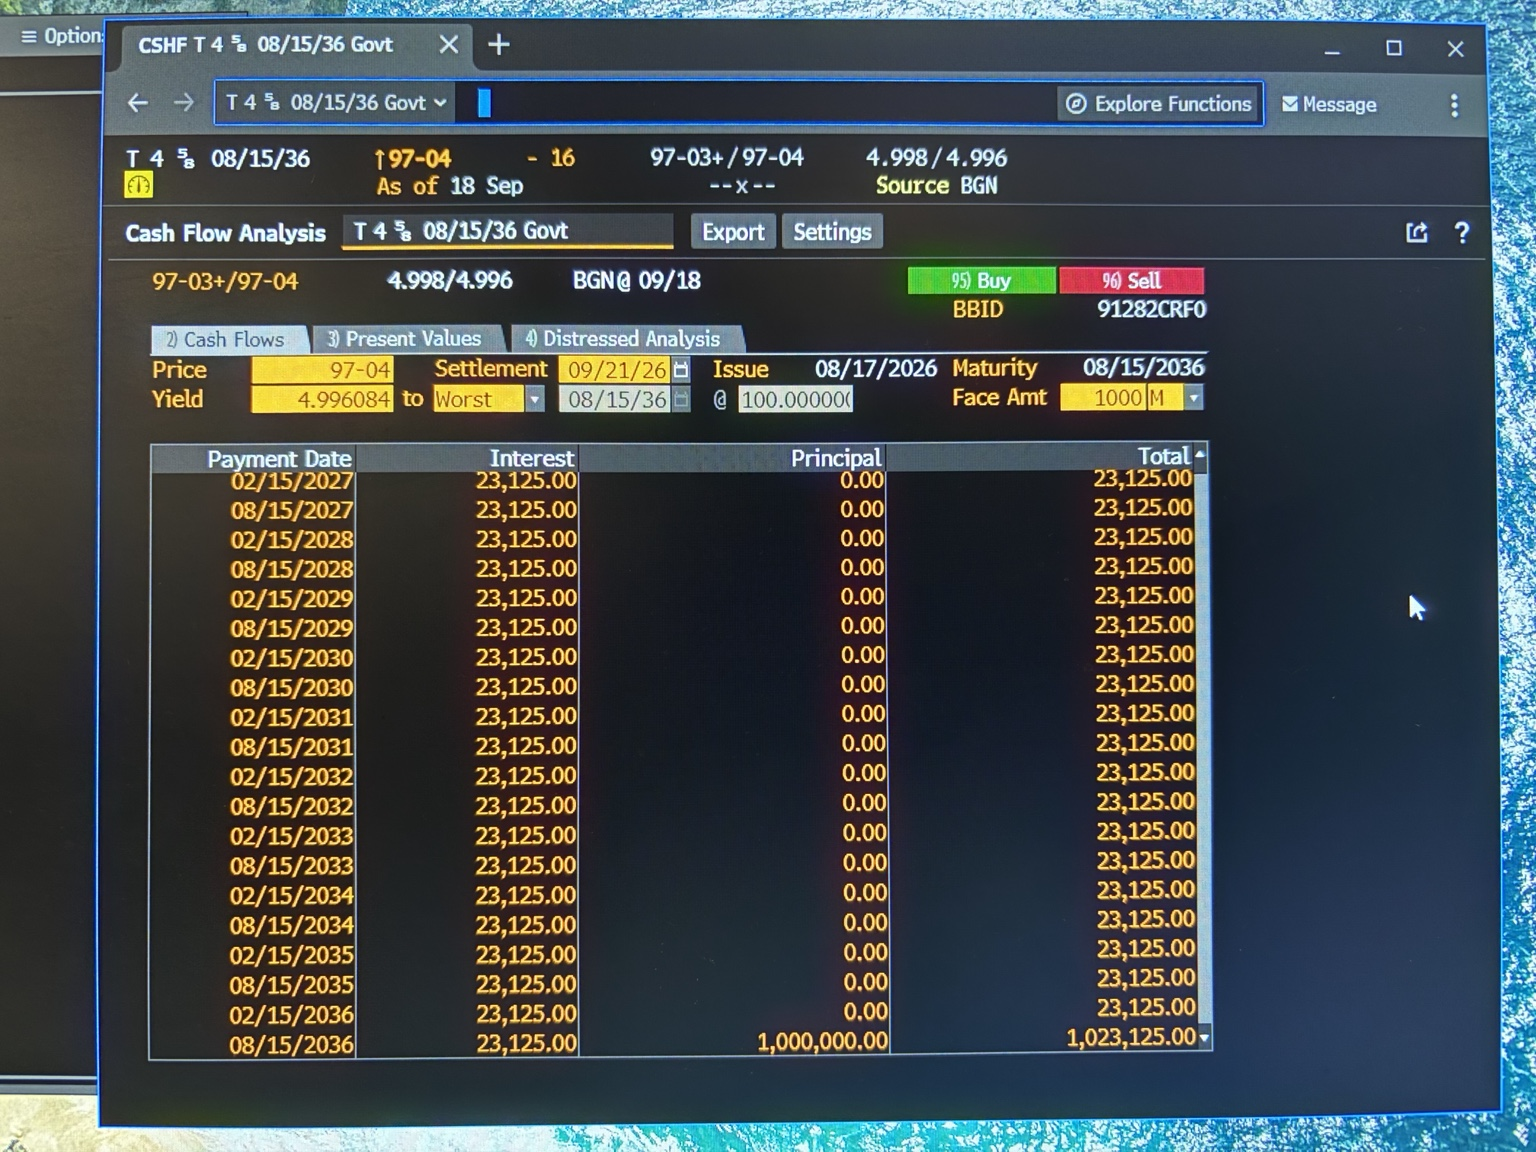

Source: [IMG_6118.jpeg](screenshot/IMG_6118.jpeg)

In [7]:
settlement_date = '2026-09-21'
observed_yield_pct = 4.997112
observed_clean_price = 97.1171875
observed_accrued = 0.46501359

result = calculator.yield_to_price(
    settlement_date=settlement_date, yield_rate=observed_yield_pct / 100)

# Use the following assertions to check your code.
# assert abs(result["accrued_interest"] - observed_accrued) <= 5e-9 + 1e-12
# assert abs(result["clean_price"] - observed_clean_price) <= abs(result["dpricedyield"]) * 5e-7 + 1e-10
display(pd.DataFrame([
    {"quantity": "clean price", "Bloomberg": observed_clean_price, "calculated": result["clean_price"]},
    {"quantity": "accrued interest", "Bloomberg": observed_accrued, "calculated": result["accrued_interest"]},
]))


,quantity,Bloomberg,calculated
0,clean price,97.117188,97.117189
1,accrued interest,0.465014,0.465014


#### Bloomberg evidence for the preceding test

**UST_2036** — settlement **2026-09-21**, clean price **97.1171875 per 100**, Street yield **4.997112%**, INT_ACC **0.46501359 per 100**. These are the observations used in the preceding test.

**YAS — input price and Street yield**

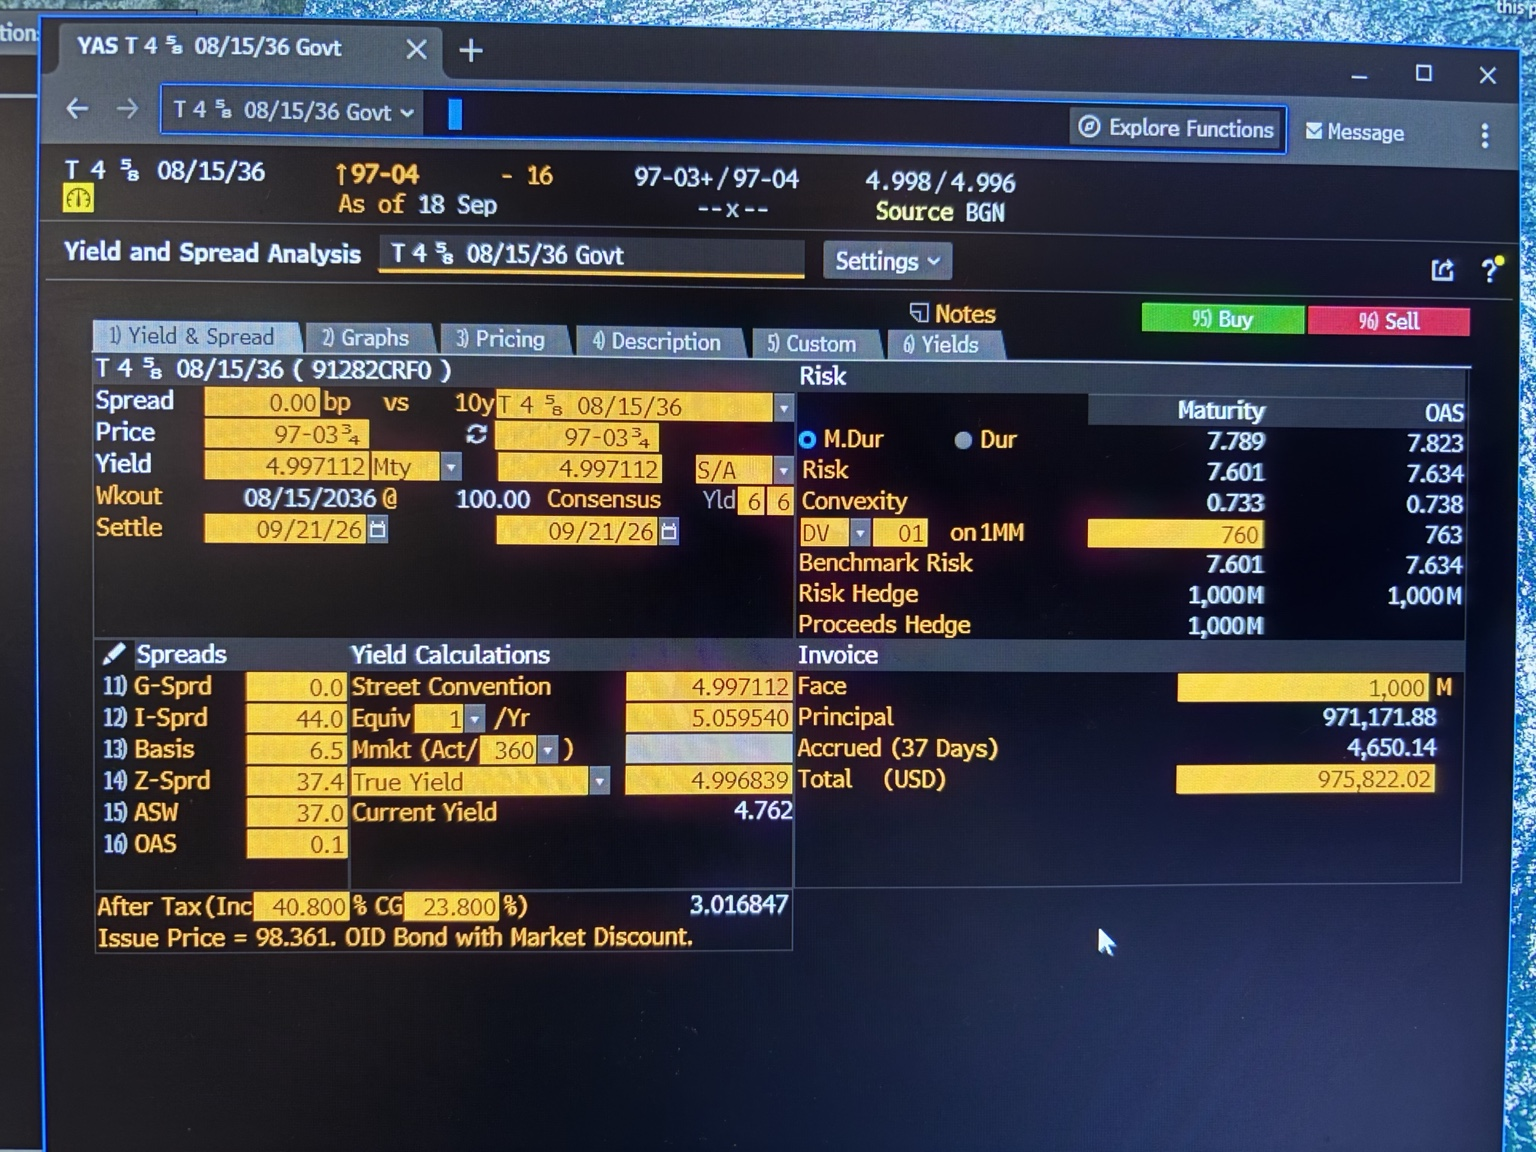

Source: [IMG_6106.jpeg](screenshot/IMG_6106.jpeg)

**FLDS — accrued interest at the same settlement**

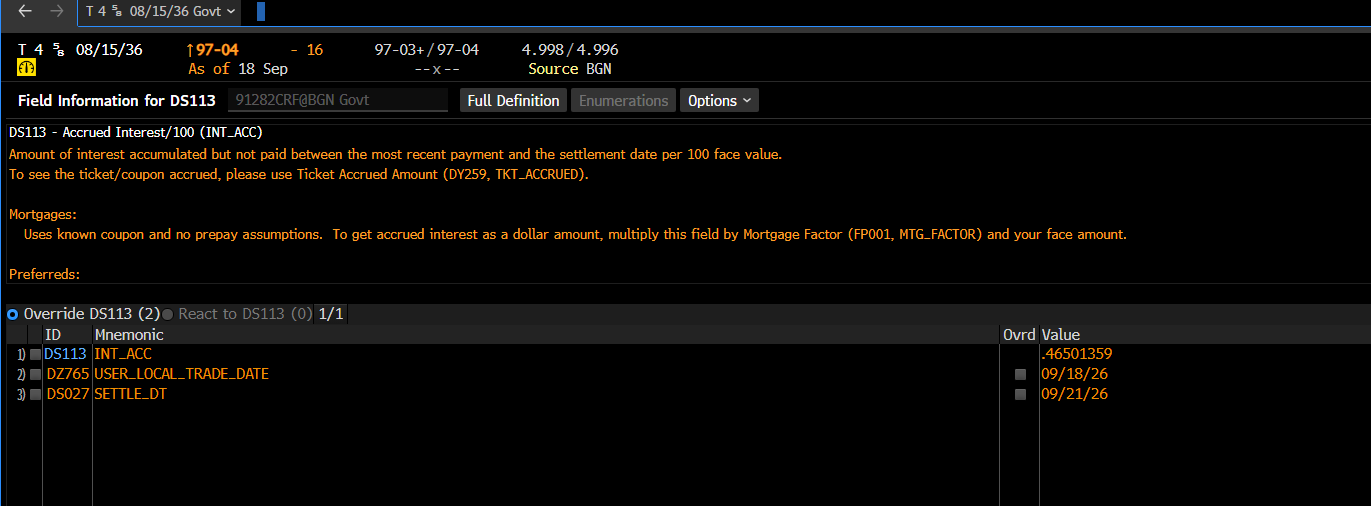

Source: [b9883ff3-a356-4eb3-892d-9903652629b3.png](screenshot/b9883ff3-a356-4eb3-892d-9903652629b3.png)

### Final regular coupon — simple discounting

In [8]:
bond_convention = {'issue date': '2023-11-15',
 'first accrual date': '2023-11-15',
 'first coupon date': '2024-05-15',
 'maturity date': '2026-11-15',
 'coupon rate': 0.04625,
 'face value': 100.0,
 'redemption': 1.0,
 'coupon accrual period': '6M',
 'accrual basis': 'ACT/ACT (ICMA)',
 'first period accrual basis': 'ACT/ACT (ICMA)',
 'last period accrual basis': 'ACT/ACT (ICMA)',
 'schedule rule': 'BACKWARD',
 'last regular coupon date': None,
 'end of month': False,
 'settlement business day convention': 'F',
 'settlement holiday convention': 'USGS',
 'settlement offset': '1D',
 'payment business day convention': 'NONE',
 'payment holiday convention': 'NONE',
 'payment offset': '0D'}

calculator = BondCalculator(bond_convention=bond_convention)
cashflows = calculator.schedule_dataframe()
display(cashflows)


,StartDate,EndDate,PaymentDate,ReferenceStart,ReferenceEnd,IsRegular,Accrued,Coupon,Principal,Total
0,2023-11-15,2024-05-15,2024-05-15,2023-11-15,2024-05-15,True,0.5,2.3125,0.0,2.3125
1,2024-05-15,2024-11-15,2024-11-15,2024-05-15,2024-11-15,True,0.5,2.3125,0.0,2.3125
2,2024-11-15,2025-05-15,2025-05-15,2024-11-15,2025-05-15,True,0.5,2.3125,0.0,2.3125
3,2025-05-15,2025-11-15,2025-11-15,2025-05-15,2025-11-15,True,0.5,2.3125,0.0,2.3125
4,2025-11-15,2026-05-15,2026-05-15,2025-11-15,2026-05-15,True,0.5,2.3125,0.0,2.3125
5,2026-05-15,2026-11-15,2026-11-15,2026-05-15,2026-11-15,True,0.5,2.3125,100.0,102.3125


#### Bloomberg cashflow evidence

**UST_2026** — original export: 1 remaining cashflows, 2026-11-15 to 2026-11-15. Export amounts use **USD 1,000,000 face**; the calculated table above uses face 100. Rescale the calculated amounts by 10,000 when comparing with the screenshot.

**CSHF**

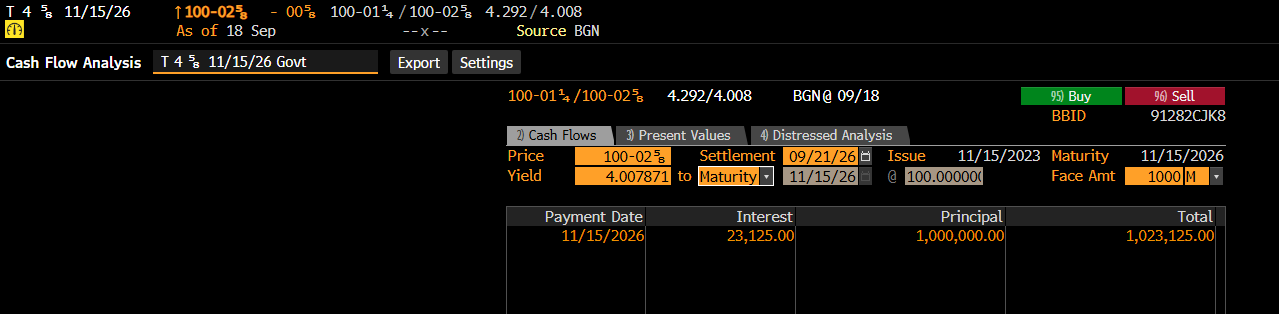

Source: [9ad6c10e-dc0f-4643-83d7-25f165ea846b.png](screenshot/9ad6c10e-dc0f-4643-83d7-25f165ea846b.png)

In [10]:
settlement_date = '2026-11-13'
observed_yield_pct = 4.521575
observed_clean_price = 100
observed_accrued = 2.28736413

result = calculator.yield_to_price(
    settlement_date=settlement_date, yield_rate=observed_yield_pct / 100)

# Use the following assertions to check your code.
assert abs(result["accrued_interest"] - observed_accrued) <= 5e-9 + 1e-12
assert abs(result["clean_price"] - observed_clean_price) <= abs(result["dpricedyield"]) * 5e-7 + 1e-10
display(pd.DataFrame([
    {"quantity": "clean price", "Bloomberg": observed_clean_price, "calculated": result["clean_price"]},
    {"quantity": "accrued interest", "Bloomberg": observed_accrued, "calculated": result["accrued_interest"]},
]))


,quantity,Bloomberg,calculated
0,clean price,100.000000,100.000000
1,accrued interest,2.287364,2.287364


#### Bloomberg evidence for the preceding test

**UST_2026** — settlement **2026-11-13**, clean price **100 per 100**, Street yield **4.521575%**, INT_ACC **2.28736413 per 100**. These are the observations used in the preceding test.

**YAS — input price and Street yield**

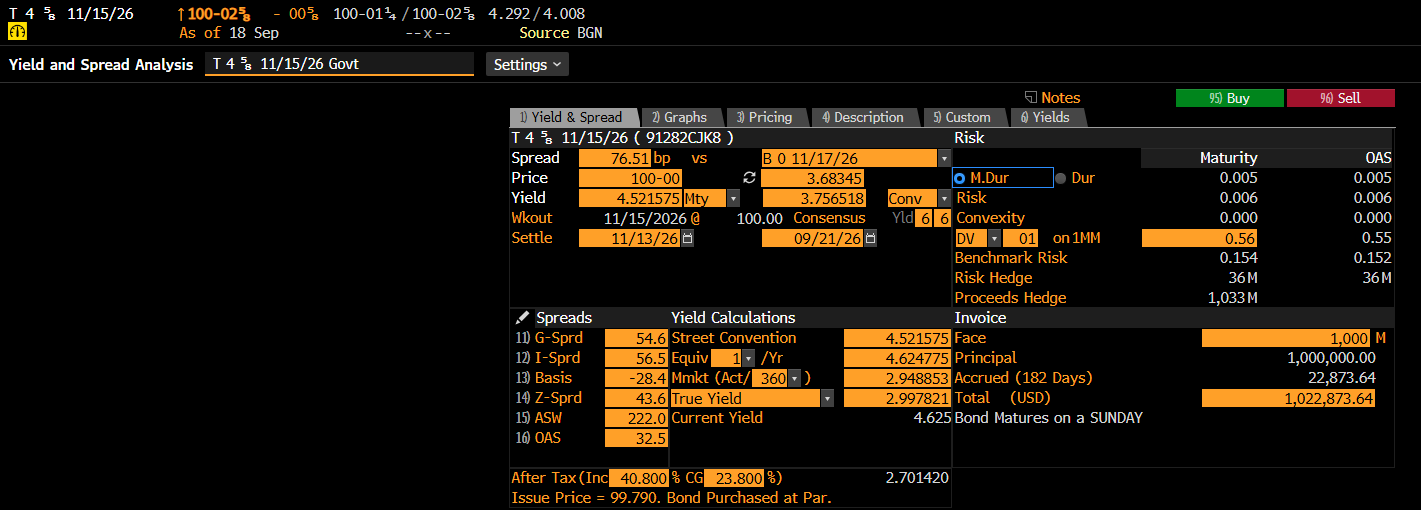

Source: [f11f4a15-d71d-44bb-9980-1eb51c2e2902.png](screenshot/f11f4a15-d71d-44bb-9980-1eb51c2e2902.png)

**FLDS — accrued interest at the same settlement**

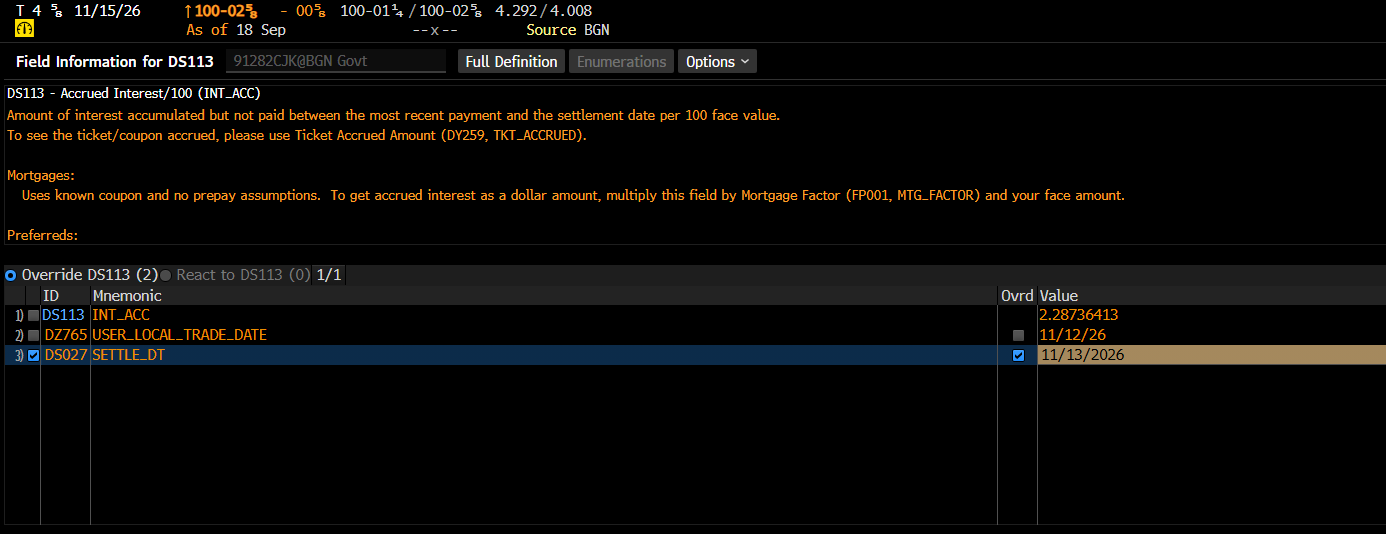

Source: [e79df28a-b0ab-45e1-8c8c-e0f914c62111.png](screenshot/e79df28a-b0ab-45e1-8c8c-e0f914c62111.png)

### META — 30/360 long first coupon

In [11]:
bond_convention = {'issue date': '2026-05-04',
 'first accrual date': '2026-05-04',
 'first coupon date': '2026-11-15',
 'maturity date': '2036-05-15',
 'coupon rate': 0.0525,
 'face value': 100.0,
 'redemption': 1.0,
 'coupon accrual period': '6M',
 'accrual basis': '30/360 (BOND BASIS)',
 'first period accrual basis': '30/360 (BOND BASIS)',
 'last period accrual basis': '30/360 (BOND BASIS)',
 'schedule rule': 'BACKWARD',
 'last regular coupon date': None,
 'end of month': False,
 'settlement business day convention': 'F',
 'settlement holiday convention': 'USGS',
 'settlement offset': '1D',
 'payment business day convention': 'NONE',
 'payment holiday convention': 'NONE',
 'payment offset': '0D'}

calculator = BondCalculator(bond_convention=bond_convention)
cashflows = calculator.schedule_dataframe()
display(cashflows)


,StartDate,EndDate,PaymentDate,ReferenceStart,ReferenceEnd,IsRegular,Accrued,Coupon,Principal,Total
0,2026-05-04,2026-11-15,2026-11-15,2026-05-15,2026-11-15,False,0.530556,2.785417,0.0,2.785417
1,2026-11-15,2027-05-15,2027-05-15,2026-11-15,2027-05-15,True,0.500000,2.625000,0.0,2.625000
2,2027-05-15,2027-11-15,2027-11-15,2027-05-15,2027-11-15,True,0.500000,2.625000,0.0,2.625000
3,2027-11-15,2028-05-15,2028-05-15,2027-11-15,2028-05-15,True,0.500000,2.625000,0.0,2.625000
4,2028-05-15,2028-11-15,2028-11-15,2028-05-15,2028-11-15,True,0.500000,2.625000,0.0,2.625000
5,2028-11-15,2029-05-15,2029-05-15,2028-11-15,2029-05-15,True,0.500000,2.625000,0.0,2.625000
6,2029-05-15,2029-11-15,2029-11-15,2029-05-15,2029-11-15,True,0.500000,2.625000,0.0,2.625000
7,2029-11-15,2030-05-15,2030-05-15,2029-11-15,2030-05-15,True,0.500000,2.625000,0.0,2.625000
8,2030-05-15,2030-11-15,2030-11-15,2030-05-15,2030-11-15,True,0.500000,2.625000,0.0,2.625000
9,2030-11-15,2031-05-15,2031-05-15,2030-11-15,2031-05-15,True,0.500000,2.625000,0.0,2.625000


#### Bloomberg cashflow evidence

**META_2036** — original export: 20 remaining cashflows, 2026-11-15 to 2036-05-15. Export amounts use **USD 1,000,000 face**; the calculated table above uses face 100. Rescale the calculated amounts by 10,000 when comparing with the screenshot.

**CSHF**

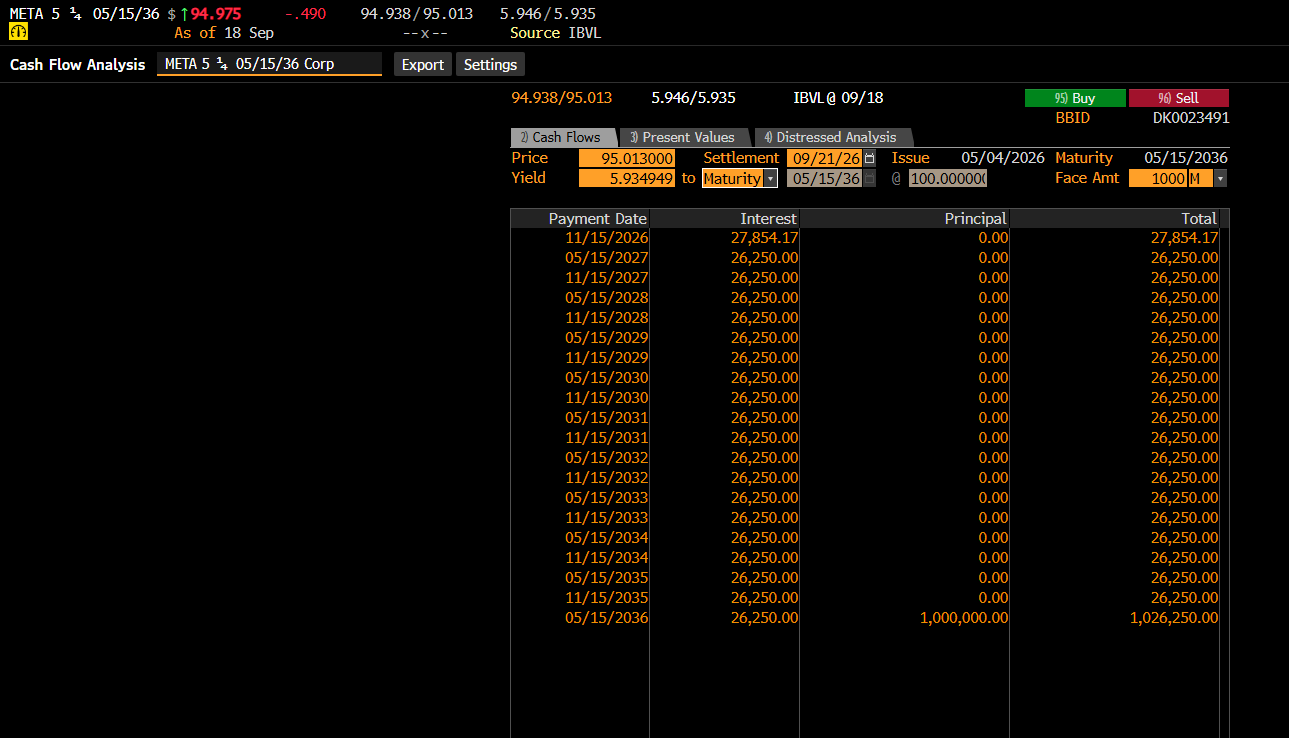

Source: [cb182845-3429-46b2-8ef8-674c44b1bc3a.png](screenshot/cb182845-3429-46b2-8ef8-674c44b1bc3a.png)

In [13]:
settlement_date = '2026-05-06'
observed_yield_pct = 5.921383
observed_clean_price = 94.9755
observed_accrued = 0.02916667

result = calculator.yield_to_price(
    settlement_date=settlement_date, yield_rate=observed_yield_pct / 100)

# Use the following assertions to check your code.
assert abs(result["accrued_interest"] - observed_accrued) <= 5e-9 + 1e-12
assert abs(result["clean_price"] - observed_clean_price) <= abs(result["dpricedyield"]) * 5e-7 + 1e-10
display(pd.DataFrame([
    {"quantity": "clean price", "Bloomberg": observed_clean_price, "calculated": result["clean_price"]},
    {"quantity": "accrued interest", "Bloomberg": observed_accrued, "calculated": result["accrued_interest"]},
]))
assert abs(cashflows.iloc[0]["Coupon"] - 100 * .0525 * 191 / 360) < 1e-12


,quantity,Bloomberg,calculated
0,clean price,94.975500,94.975497
1,accrued interest,0.029167,0.029167


#### Bloomberg evidence for the preceding test

**META_2036** — settlement **2026-05-06**, clean price **94.9755 per 100**, Street yield **5.921383%**, INT_ACC **0.02916667 per 100**. These are the observations used in the preceding test.

**YAS — input price and Street yield**

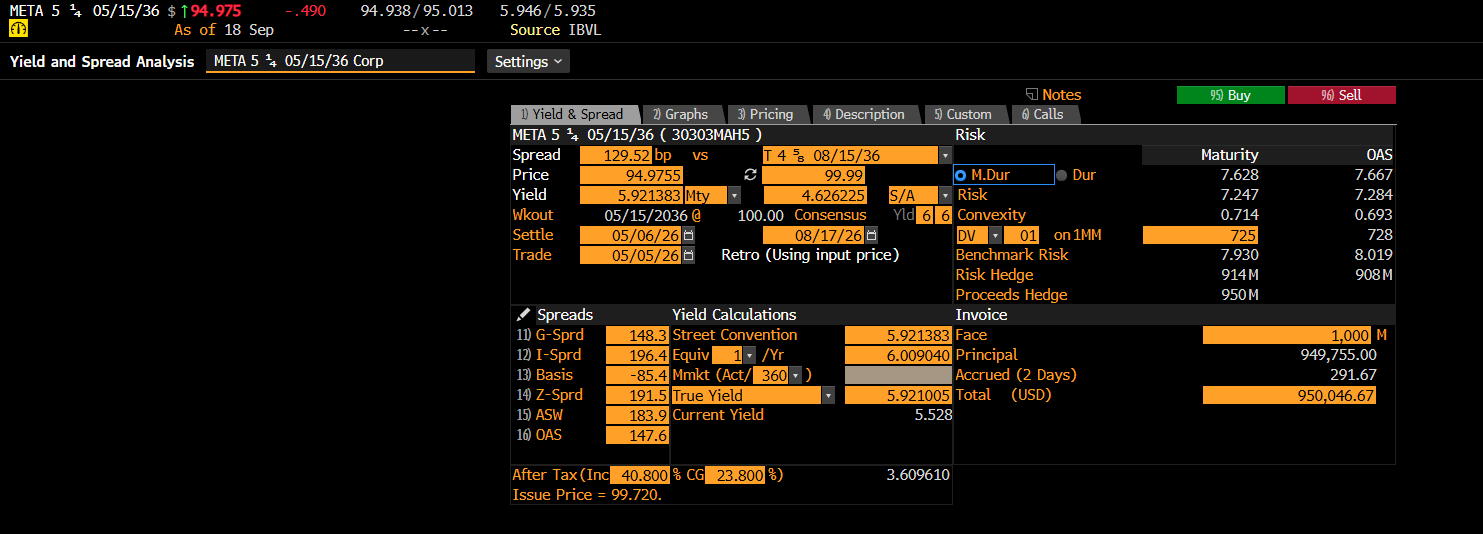

Source: [3fa58092-adfc-4f3b-bb75-4001b58c1030.png](screenshot/3fa58092-adfc-4f3b-bb75-4001b58c1030.png)

**FLDS — accrued interest at the same settlement**

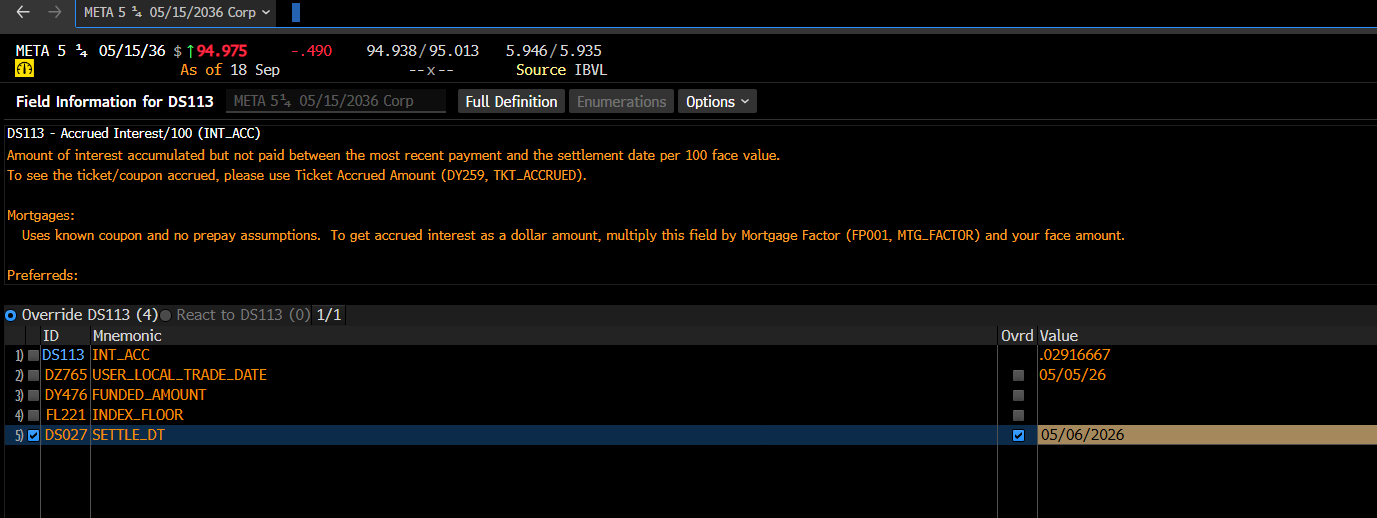

Source: [d79f7a1b-a3d5-42c5-910c-9e67379d76e0.png](screenshot/d79f7a1b-a3d5-42c5-910c-9e67379d76e0.png)

### HMLGLO — ICMA long first coupon

In [14]:
bond_convention = {'issue date': '2025-06-18',
 'first accrual date': '2025-06-18',
 'first coupon date': '2026-02-15',
 'maturity date': '2030-02-15',
 'coupon rate': 0.08,
 'face value': 100.0,
 'redemption': 1.0,
 'coupon accrual period': '6M',
 'accrual basis': 'ACT/ACT (ICMA)',
 'first period accrual basis': 'ACT/ACT (ICMA)',
 'last period accrual basis': 'ACT/ACT (ICMA)',
 'schedule rule': 'BACKWARD',
 'last regular coupon date': None,
 'end of month': False,
 'settlement business day convention': 'F',
 'settlement holiday convention': 'USGS',
 'settlement offset': '2D',
 'payment business day convention': 'NONE',
 'payment holiday convention': 'NONE',
 'payment offset': '0D'}

calculator = BondCalculator(bond_convention=bond_convention)
cashflows = calculator.schedule_dataframe()
display(cashflows)


,StartDate,EndDate,PaymentDate,ReferenceStart,ReferenceEnd,IsRegular,Accrued,Coupon,Principal,Total
0,2025-06-18,2026-02-15,2026-02-15,2025-08-15,2026-02-15,False,0.660221,5.281768,0.0,5.281768
1,2026-02-15,2026-08-15,2026-08-15,2026-02-15,2026-08-15,True,0.500000,4.000000,0.0,4.000000
2,2026-08-15,2027-02-15,2027-02-15,2026-08-15,2027-02-15,True,0.500000,4.000000,0.0,4.000000
3,2027-02-15,2027-08-15,2027-08-15,2027-02-15,2027-08-15,True,0.500000,4.000000,0.0,4.000000
4,2027-08-15,2028-02-15,2028-02-15,2027-08-15,2028-02-15,True,0.500000,4.000000,0.0,4.000000
5,2028-02-15,2028-08-15,2028-08-15,2028-02-15,2028-08-15,True,0.500000,4.000000,0.0,4.000000
6,2028-08-15,2029-02-15,2029-02-15,2028-08-15,2029-02-15,True,0.500000,4.000000,0.0,4.000000
7,2029-02-15,2029-08-15,2029-08-15,2029-02-15,2029-08-15,True,0.500000,4.000000,0.0,4.000000
8,2029-08-15,2030-02-15,2030-02-15,2029-08-15,2030-02-15,True,0.500000,4.000000,100.0,104.000000


#### Bloomberg cashflow evidence

**HMLGLO_2030** — original export: 9 remaining cashflows, 2026-02-15 to 2030-02-15. Export amounts use **USD 1,000,000 face**; the calculated table above uses face 100. Rescale the calculated amounts by 10,000 when comparing with the screenshot.

**CSHF**

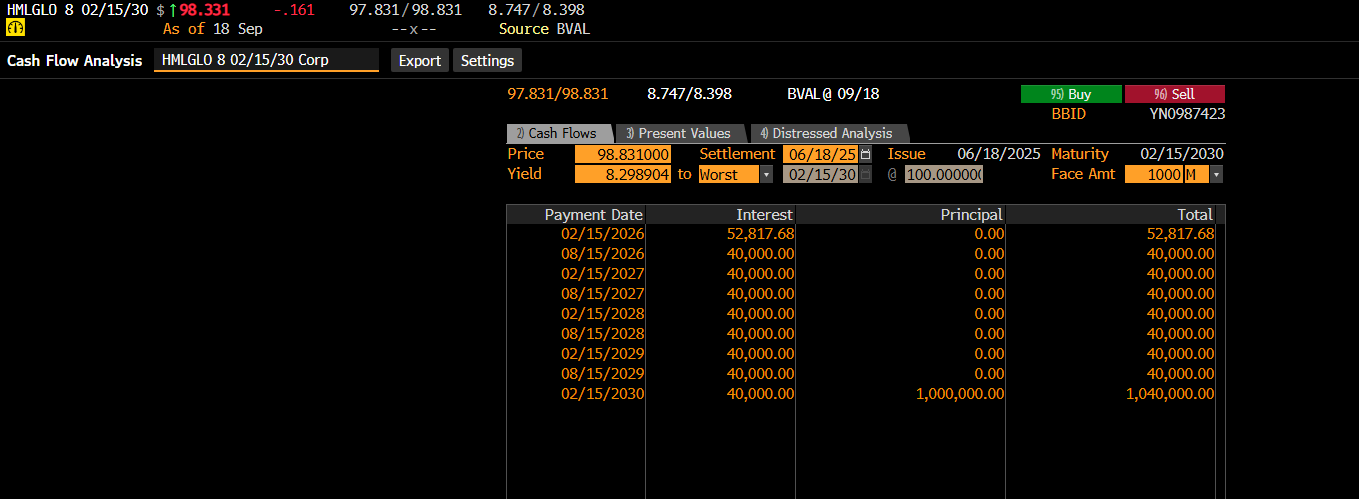

Source: [bc0e5a4a-42ef-4815-979a-48c0a890399a.png](screenshot/bc0e5a4a-42ef-4815-979a-48c0a890399a.png)

In [15]:
settlement_date = '2025-09-15'
observed_yield_pct = 7.9858
observed_clean_price = 100
observed_accrued = 1.95568100

result = calculator.yield_to_price(
    settlement_date=settlement_date, yield_rate=observed_yield_pct / 100)

# Use the following assertions to check your code.
assert abs(result["accrued_interest"] - observed_accrued) <= 5e-9 + 1e-12
assert abs(result["clean_price"] - observed_clean_price) <= abs(result["dpricedyield"]) * 5e-7 + 1e-10
display(pd.DataFrame([
    {"quantity": "clean price", "Bloomberg": observed_clean_price, "calculated": result["clean_price"]},
    {"quantity": "accrued interest", "Bloomberg": observed_accrued, "calculated": result["accrued_interest"]},
]))
assert abs(cashflows.iloc[0]["Coupon"] - 4 * (58 / 181 + 1)) < 1e-12


,quantity,Bloomberg,calculated
0,clean price,100.000000,100.000001
1,accrued interest,1.955681,1.955681


#### Bloomberg evidence for the preceding test

**HMLGLO_2030** — settlement **2025-09-15**, clean price **100 per 100**, Street yield **7.985800%**, INT_ACC **1.95568100 per 100**. These are the observations used in the preceding test.

**YAS — input price and Street yield**

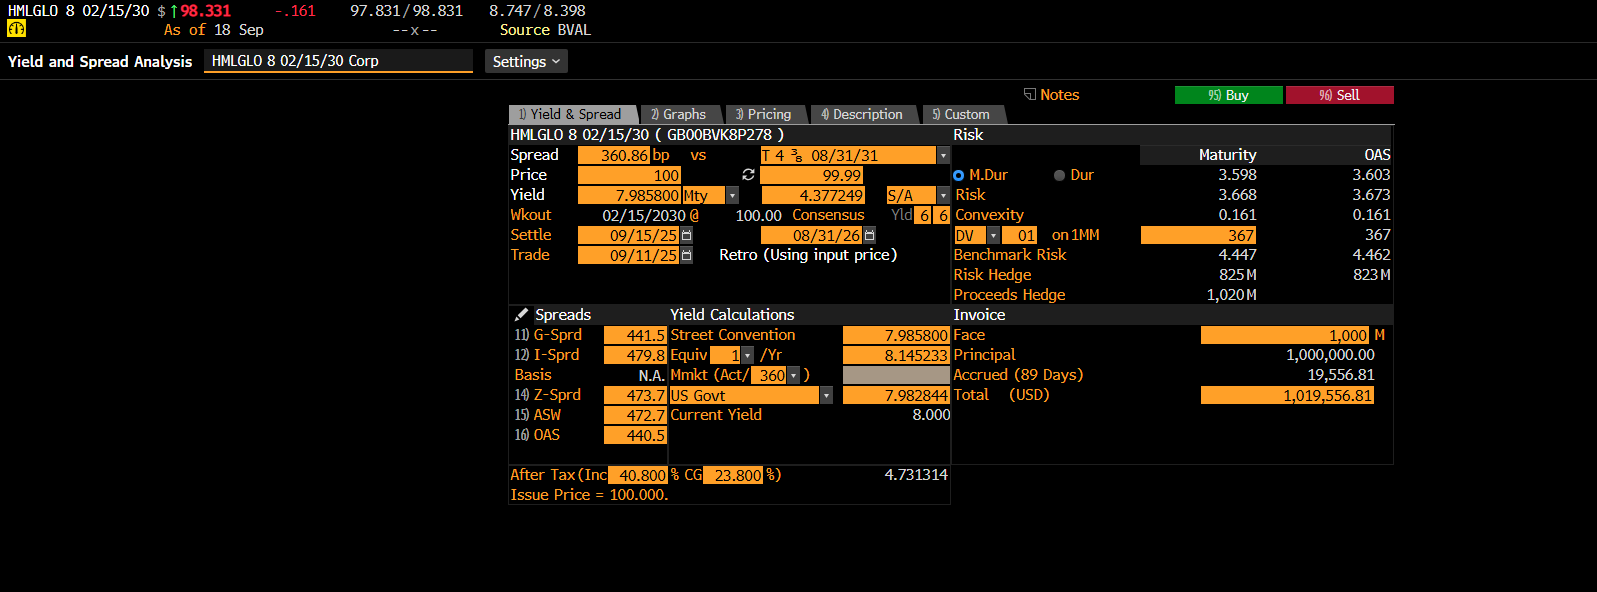

Source: [48559326-afcb-4418-a8c6-c88f47779cb9.png](screenshot/48559326-afcb-4418-a8c6-c88f47779cb9.png)

**FLDS — accrued interest at the same settlement**

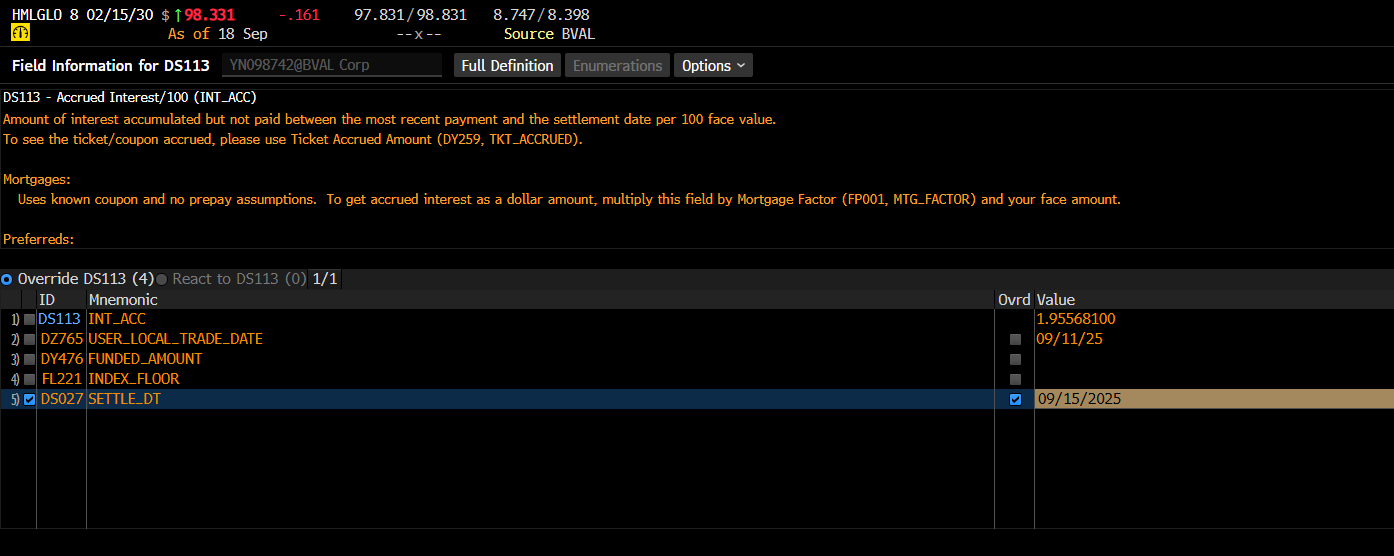

Source: [c13dadbb-f1ad-449a-a8b2-713aecb19563.png](screenshot/c13dadbb-f1ad-449a-a8b2-713aecb19563.png)

### KSA — 30/360 short final coupon

In [16]:
bond_convention = {'issue date': '2020-02-03',
 'first accrual date': '2020-02-03',
 'first coupon date': '2020-08-03',
 'maturity date': '2055-01-21',
 'coupon rate': 0.0375,
 'face value': 100.0,
 'redemption': 1.0,
 'coupon accrual period': '6M',
 'accrual basis': 'ISMA-30/360',
 'first period accrual basis': 'ISMA-30/360',
 'last period accrual basis': 'ISMA-30/360',
 'schedule rule': 'BACKWARD',
 'last regular coupon date': '2054-08-03',
 'end of month': False,
 'settlement business day convention': 'F',
 'settlement holiday convention': None,
 'settlement offset': None,
 'payment business day convention': 'NONE',
 'payment holiday convention': 'NONE',
 'payment offset': '0D'}

calculator = BondCalculator(bond_convention=bond_convention)
cashflows = calculator.schedule_dataframe()
display(cashflows)


,StartDate,EndDate,PaymentDate,ReferenceStart,ReferenceEnd,IsRegular,Accrued,Coupon,Principal,Total
0,2020-02-03,2020-08-03,2020-08-03,2020-02-03,2020-08-03,True,0.500000,1.875,0.0,1.875
1,2020-08-03,2021-02-03,2021-02-03,2020-08-03,2021-02-03,True,0.500000,1.875,0.0,1.875
2,2021-02-03,2021-08-03,2021-08-03,2021-02-03,2021-08-03,True,0.500000,1.875,0.0,1.875
3,2021-08-03,2022-02-03,2022-02-03,2021-08-03,2022-02-03,True,0.500000,1.875,0.0,1.875
4,2022-02-03,2022-08-03,2022-08-03,2022-02-03,2022-08-03,True,0.500000,1.875,0.0,1.875
...,...,...,...,...,...,...,...,...,...,...
65,2052-08-03,2053-02-03,2053-02-03,2052-08-03,2053-02-03,True,0.500000,1.875,0.0,1.875
66,2053-02-03,2053-08-03,2053-08-03,2053-02-03,2053-08-03,True,0.500000,1.875,0.0,1.875
67,2053-08-03,2054-02-03,2054-02-03,2053-08-03,2054-02-03,True,0.500000,1.875,0.0,1.875
68,2054-02-03,2054-08-03,2054-08-03,2054-02-03,2054-08-03,True,0.500000,1.875,0.0,1.875


#### Bloomberg cashflow evidence

**KSA_2055** — original export: 57 remaining cashflows, 2027-02-03 to 2055-01-21. Export amounts use **USD 1,000,000 face**; the calculated table above uses face 100. Rescale the calculated amounts by 10,000 when comparing with the screenshot.

The screenshot shows only the lower portion of the cashflows, so it cannot verify all the exported rows.

**CSHF**

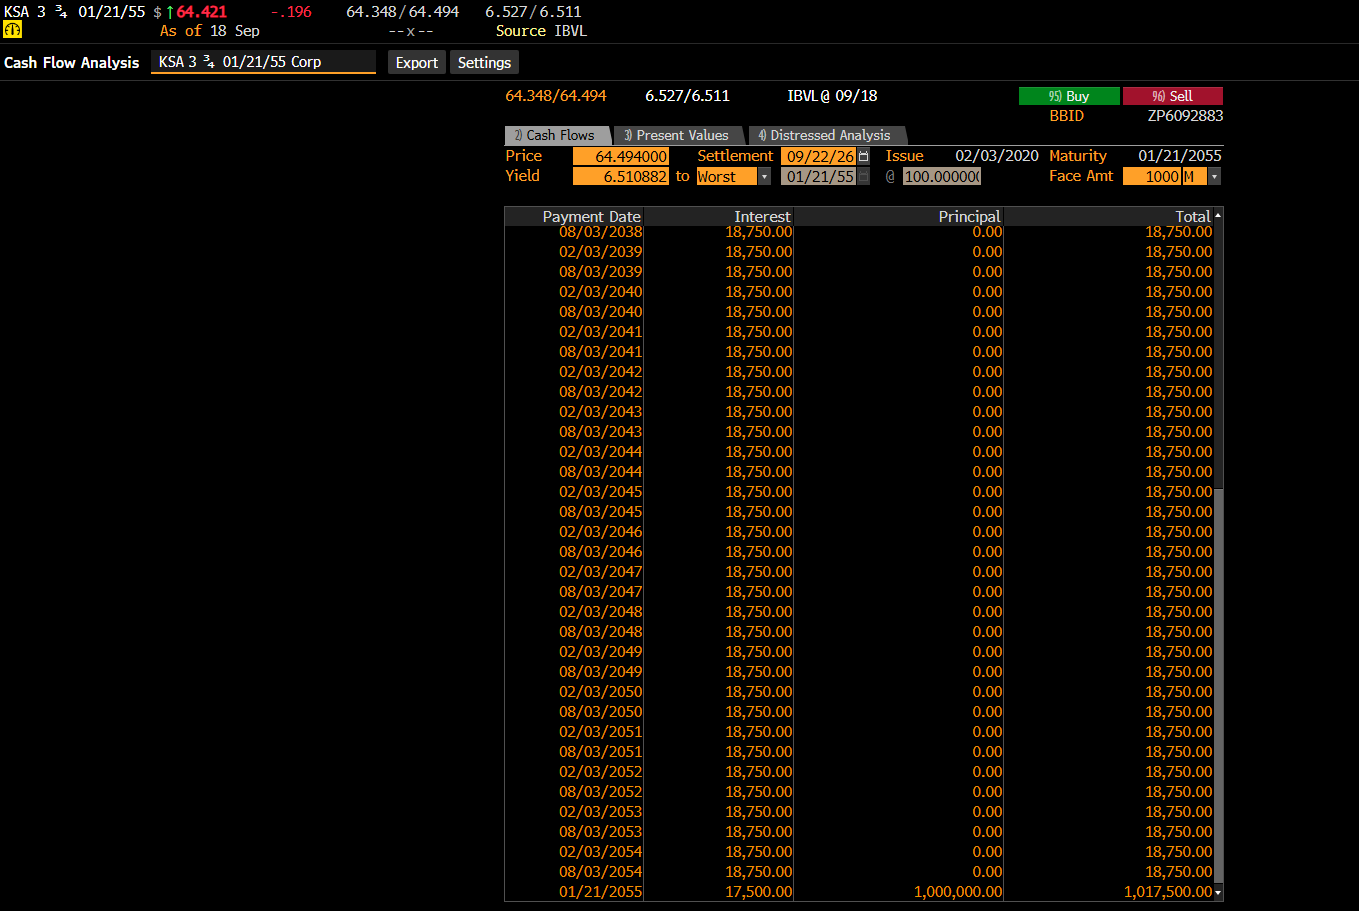

Source: [d379a0a0-c5fc-4265-a203-fcde7222ef7a.png](screenshot/d379a0a0-c5fc-4265-a203-fcde7222ef7a.png)

In [17]:
settlement_date = '2054-08-10'
observed_yield_pct = 3.747268
observed_clean_price = 100
observed_accrued = 0.07291667

result = calculator.yield_to_price(
    settlement_date=settlement_date, yield_rate=observed_yield_pct / 100)

# Use the following assertions to check your code.
assert abs(result["accrued_interest"] - observed_accrued) <= 5e-9 + 1e-12
assert abs(result["clean_price"] - observed_clean_price) <= abs(result["dpricedyield"]) * 5e-7 + 1e-10
display(pd.DataFrame([
    {"quantity": "clean price", "Bloomberg": observed_clean_price, "calculated": result["clean_price"]},
    {"quantity": "accrued interest", "Bloomberg": observed_accrued, "calculated": result["accrued_interest"]},
]))
assert cashflows.iloc[-2]["EndDate"] == "2054-08-03"
assert abs(cashflows.iloc[-1]["Coupon"] - 1.75) < 1e-12


,quantity,Bloomberg,calculated
0,clean price,100.000000,100.000000
1,accrued interest,0.072917,0.072917


#### Bloomberg evidence for the preceding test

**KSA_2055** — settlement **2054-08-10**, clean price **100 per 100**, Street yield **3.747268%**, INT_ACC **0.07291667 per 100**. These are the observations used in the preceding test.

**YAS — input price and Street yield**

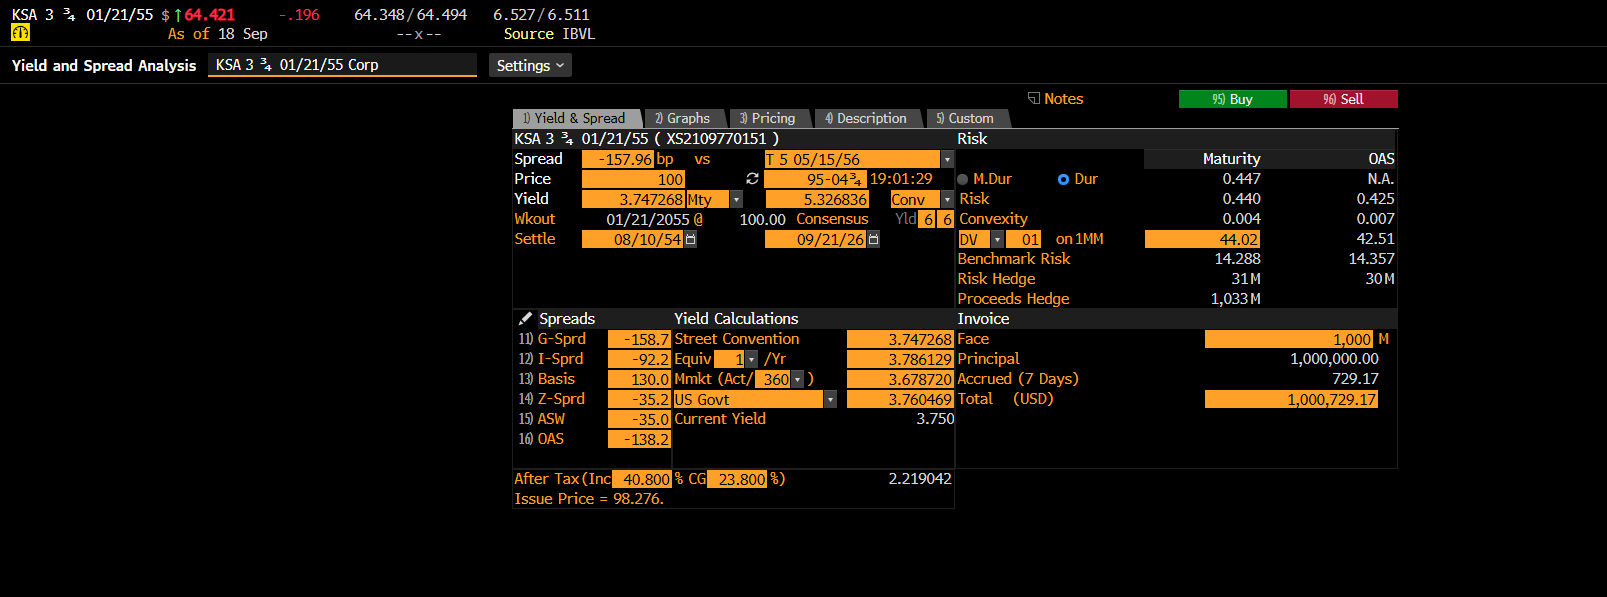

Source: [0a8d21da-5ea7-4feb-9362-2c0554d37b2b.png](screenshot/0a8d21da-5ea7-4feb-9362-2c0554d37b2b.png)

**FLDS — accrued interest at the same settlement**

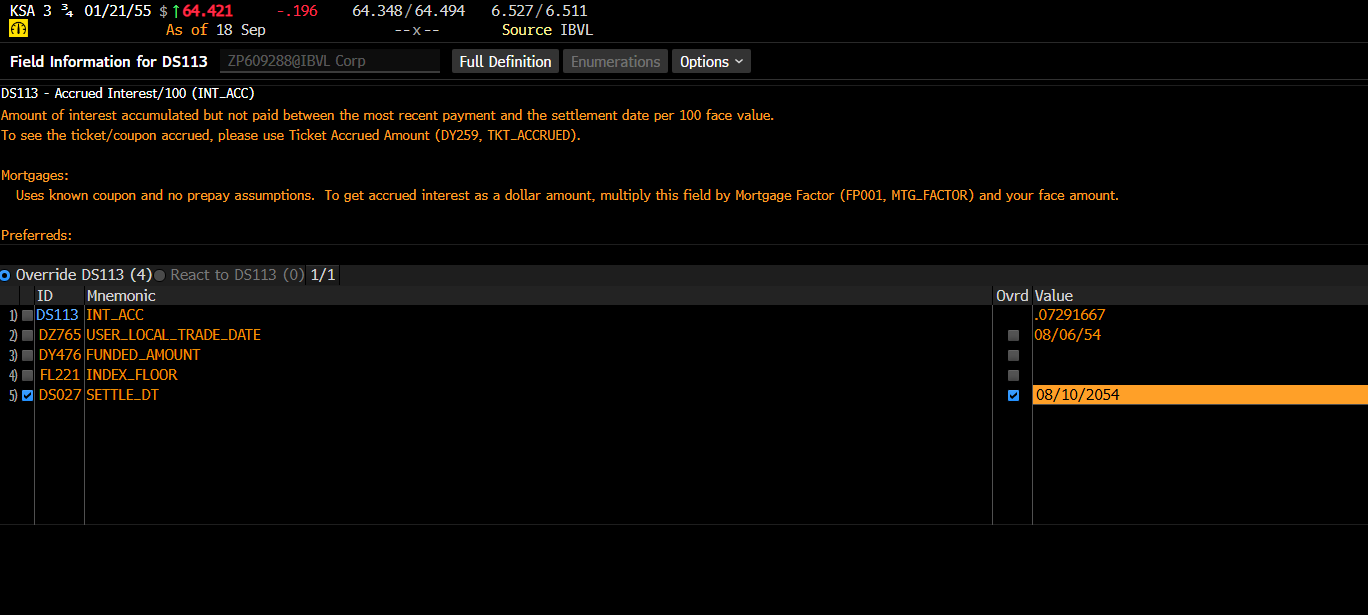

Source: [57885e2e-8eb9-4f76-9840-3c9d5f160133.png](screenshot/57885e2e-8eb9-4f76-9840-3c9d5f160133.png)